# 1A Initial data exploration
## Opening Data

In [4]:
import numpy as np
import pandas as pd
import sklearn as sk
import seaborn as sns

In [5]:
data_path = "./32130_2026A_88.csv"
adata = pd.read_csv(data_path)
# adata
adata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   source ID             3000 non-null   int64  
 1   age                   3000 non-null   int64  
 2   gender                3000 non-null   object 
 3   marital_status        3000 non-null   object 
 4   education_level       3000 non-null   object 
 5   annual_income         3000 non-null   float64
 6   monthly_income        3000 non-null   float64
 7   employment_status     3000 non-null   object 
 8   debt_to_income_ratio  3000 non-null   float64
 9   credit_score          3000 non-null   int64  
 10  loan_amount           3000 non-null   float64
 11  loan_purpose          3000 non-null   object 
 12  interest_rate         3000 non-null   float64
 13  loan_term             3000 non-null   int64  
 14  installment           3000 non-null   float64
 15  num_of_open_accounts 

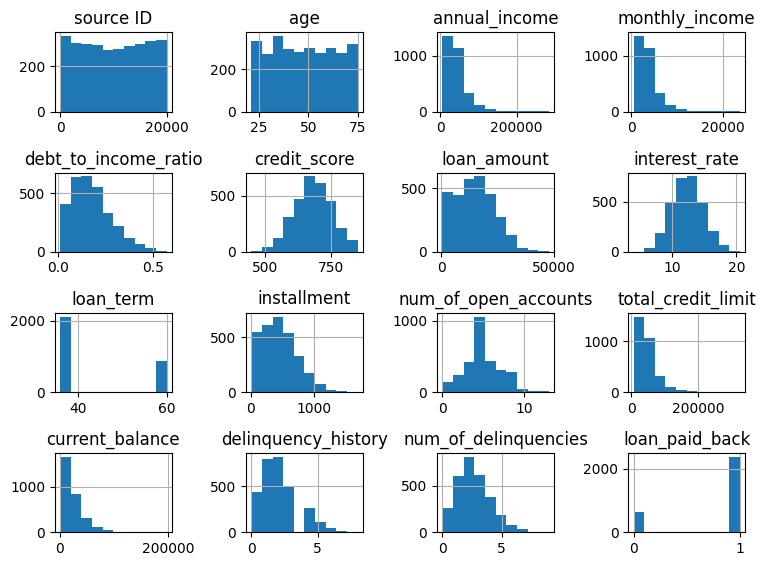

In [6]:
import matplotlib.pyplot as plt

adata.hist(bins=10)
plt.tight_layout(rect=(0, 0, 1.2, 1.2))

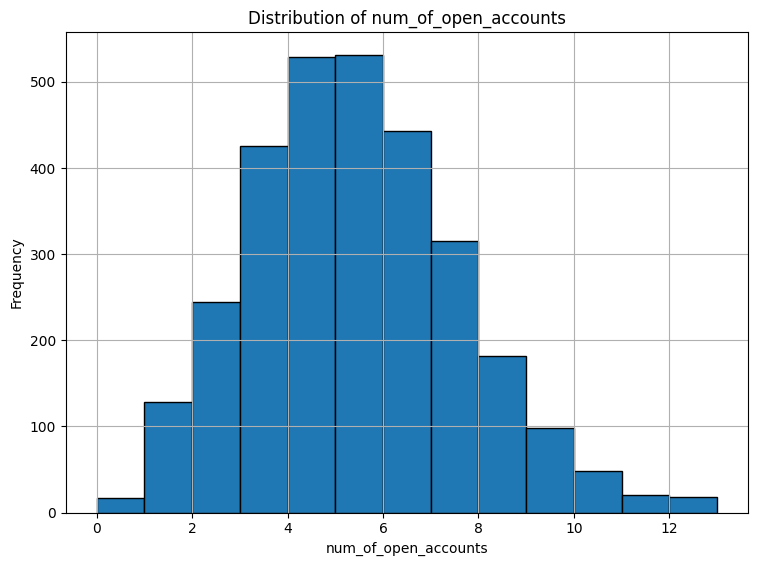

In [7]:
# edit plot
adata['num_of_open_accounts'].hist(bins=13, edgecolor='black')
plt.xlabel('num_of_open_accounts')
plt.ylabel('Frequency')
plt.title('Distribution of num_of_open_accounts')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))

In [8]:
print('Unique values before mapping adjustment:')
print(f"Gender unique values: {adata['gender'].unique()}")
print(f"Marital Status unique values: {adata['marital_status'].unique()}")
print(f"Education Level unique values: {adata['education_level'].unique()}")
print(f"Employment Status unique values: {adata['employment_status'].unique()}")

adata['gender'] = adata['gender'].map({'Female': 0, 'Male': 1, 'Other': 2}) # 0: Female, 1: Male, 2: Other
adata['marital_status'] = adata['marital_status'].map({'Single': 0, 'Married': 1, 'Divorced': 2, 'Widowed': 3}) # 0: Single, 1: Married, 2: Divorced, 3: Widowed
adata['education_level'] = adata['education_level'].map({
    'High School': 0, 'Bachelor\'s': 1, 'Master\'s': 2, 'PhD': 3, 'Other': 4
}) # 0: High School, 1: Bachelor's, 2: Master's, 3: PhD, 4: Other
adata['employment_status'] = adata['employment_status'].map({
    'Student': 0, 'Unemployed': 1, 'Employed': 2, 'Retired': 3, 'Self-employed': 4
}) # 0: Student, 1: Unemployed, 2: Employed, 3: Retired, 4: Self-employed

print("Categorical columns encoded to numerical types.")
adata.info()

Unique values before mapping adjustment:
Gender unique values: ['Male' 'Female' 'Other']
Marital Status unique values: ['Married' 'Divorced' 'Single' 'Widowed']
Education Level unique values: ["Bachelor's" "Master's" 'High School' 'Other' 'PhD']
Employment Status unique values: ['Employed' 'Student' 'Retired' 'Self-employed' 'Unemployed']
Categorical columns encoded to numerical types.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   source ID             3000 non-null   int64  
 1   age                   3000 non-null   int64  
 2   gender                3000 non-null   int64  
 3   marital_status        3000 non-null   int64  
 4   education_level       3000 non-null   int64  
 5   annual_income         3000 non-null   float64
 6   monthly_income        3000 non-null   float64
 7   employment_status     3000 non-null   in

In [9]:
# one plot for attribute
numerical_features_idx = adata.columns.get_indexer(adata.select_dtypes(['int64','float64']).columns)
numerical_features = adata.columns[numerical_features_idx]

pp = sns.pairplot(adata[numerical_features], height=1.8, aspect=1.8,
                  plot_kws=dict(edgecolor="k", linewidth=0.2),
                  diag_kind="kde", diag_kws=dict(fill=True))

fig = pp.fig
fig.subplots_adjust(top=0.93, wspace=0.3)
t = fig.suptitle('Import data Pairwise Plots', fontsize=14)

Output hidden; open in https://colab.research.google.com to view.

The values in the matrix range from -1 to 1, indicating the strength and direction of the linear relationship: 1: Perfect positive linear correlation (as one variable increases, the other increases proportionally). -1: Perfect negative linear correlation (as one variable increases, the other decreases proportionally). 0: No linear correlation.

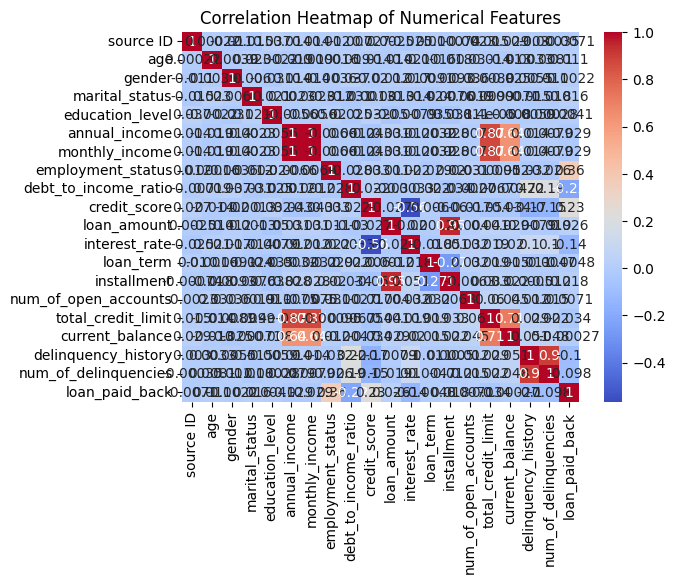

In [10]:
correlation_matrix = adata[numerical_features].corr()
# correlation_matrix = adata.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

<Axes: xlabel='age', ylabel='annual_income'>

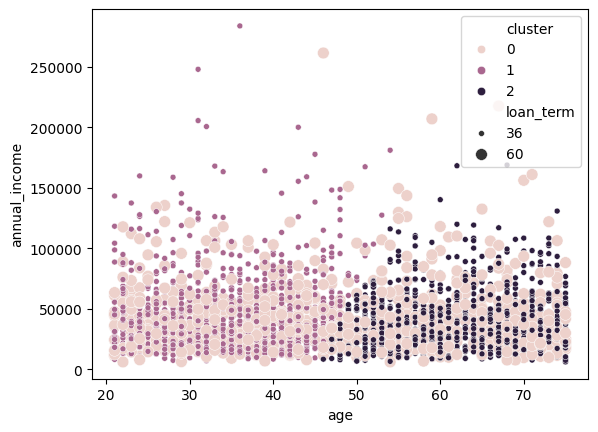

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select the features for clustering
features_for_clustering = ['age', 'annual_income', 'loan_term']
X = adata[features_for_clustering]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering (starting with 3 clusters)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
adata['cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x='age', y='annual_income', size="loan_term", hue='cluster', data=adata)